#### ARIMA

1.  ARIMA stands for Auto Regression Integrated Moving Average.

2.  It is made up of three components.

    (a.)    AR ==============>   Auto Regression. It represents p value.

            (i) It is used to compare the correlation of the current value with the previous values.

    (b.)    I   =============>   Integrated     . It represents d value.

            (i)    It is used to remove the trend.

    (c.)    MA  =============>   Moving Average . It represents q value.

            (i) It uses the previous error terms to improvise the future values.


#### Problem statement:---

1.      The main aim of thie problem statement is 

        (a.)    to understand the values of p,d,q

        (b.)    to build an ARIMA model

        (c.)    to predict the future values for the passengers.


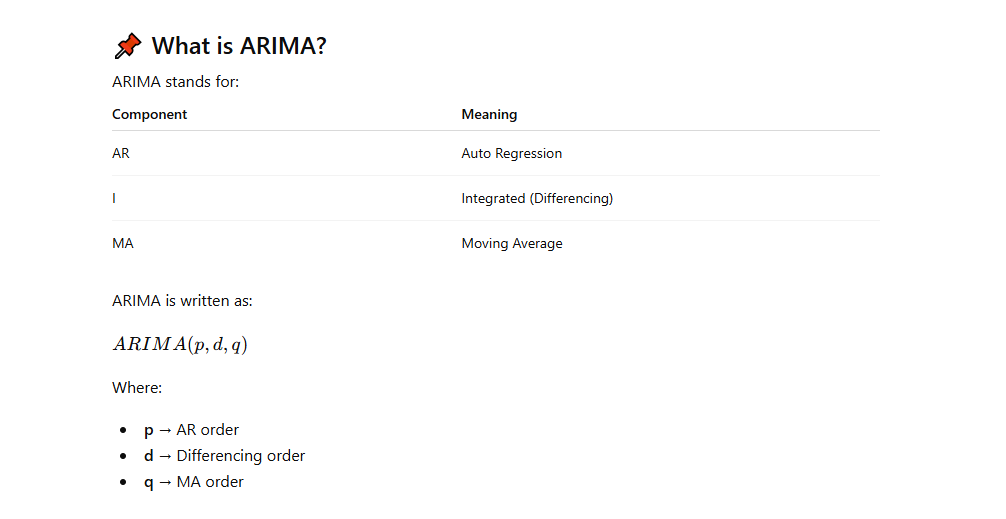


#### Step 1: Import all the necessary libraries

In [1457]:
import      numpy                   as      np
import      pandas                  as      pd
import      matplotlib.pyplot       as      plt
import      seaborn                 as      sns

from        statsmodels.tsa.arima.model     import  ARIMA

import      warnings
warnings.filterwarnings("ignore")

#### Step 2: Load the dataset

In [1458]:
#### Load the dataset

df = pd.read_csv('AirPassengers.csv')

In [1459]:
df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


#### OBSERVATIONS:

1.  The above dataset represents the airline passengers data for the starting date of each month beginning from 1949 till 1960.

#### Step 3: Perform Data Exploration

In [1460]:
#### get the first five rows of the dataset

df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [1461]:
#### get the last five rows of the dataset

df.tail()

,date,value
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


In [1462]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 144


In [1463]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (144, 2)


In [1464]:
#### get the column used in the dataset

df.columns

Index(['date', 'value'], dtype='object')

In [1465]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   value   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


#### Step 4: Perform Data Cleaning and Feature Engineering

In [1466]:
#### Convert the object type of date column to date

df['date']  =   pd.to_datetime(df['date'])

In [1467]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    144 non-null    datetime64[ns]
 1   value   144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


#### OBSERVATIONS:

1.  The date column has been converted from 'object' type to 'datetime' type.

In [1468]:
#### To set the date column as an index

df.set_index('date',inplace=True)

In [1469]:
df.head()

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


#### OBSERVATIONS:

1.  The date column has been set as an index.

In [1470]:
#### To check for the NULL records in the dataframe

df.isnull().sum()

value    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1471]:
#### Rename the column name 'value' to 'Passengers'

df.rename(columns={'value':'Passengers'},inplace=True)

#### OBSERVATIONS:

1.  The column name 'value' has been renamed to 'Passenegers'.

#### Step 5: Plot the time series data

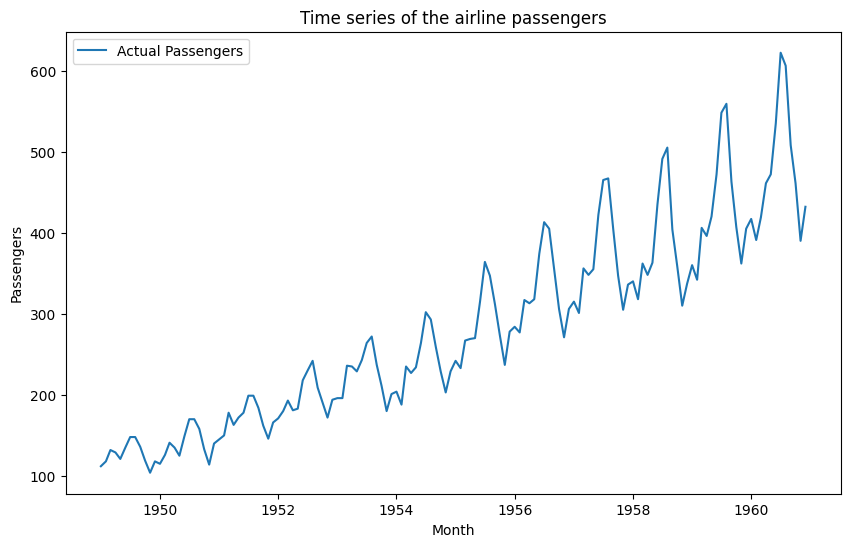

In [1472]:
plt.figure(figsize=(10,6))

#### plot the original time series
plt.plot(df.index, df['Passengers'], label = 'Actual Passengers')

#### give the title of the graph
plt.title('Time series of the airline passengers')

#### give the x axis of the graph
plt.xlabel('Month')

#### give the y-axis of the graph
plt.ylabel('Passengers')

#### give the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the passengers data for the starting date of every month starting from 1944 till 1960.

2.  With the increase in years, the number of passengers also increases, so the trned also increases.

3.  As the trend continuously increases in the upward direction, so the time series is non stationary in nature.

#### Step 6: Divide the data into training and testing data

In [1473]:
#### Training data

train=df.iloc[:120]

In [1474]:
#### Testing data

test=df.iloc[120:]

In [1475]:
print("Training data is:", train)

Training data is:             Passengers
date                  
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
...                ...
1958-08-01         505
1958-09-01         404
1958-10-01         359
1958-11-01         310
1958-12-01         337

[120 rows x 1 columns]


In [1476]:
print("Testing data is:", test)

Testing data is:             Passengers
date                  
1959-01-01         360
1959-02-01         342
1959-03-01         406
1959-04-01         396
1959-05-01         420
1959-06-01         472
1959-07-01         548
1959-08-01         559
1959-09-01         463
1959-10-01         407
1959-11-01         362
1959-12-01         405
1960-01-01         417
1960-02-01         391
1960-03-01         419
1960-04-01         461
1960-05-01         472
1960-06-01         535
1960-07-01         622
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432


#### OBSERVATIONS:

1.  The dataset is divided into the training and testing data.

2.  This is done because :--------------

    (a.)    Each time series data has a time order.

    (b.)    The training is performed on the past data and the testing is performed on the future data.

#### Step 7: Build ARIMA Model

In [1477]:
from    statsmodels.tsa.arima.model import  ARIMA

#### Create an object for ARIMA

arima = ARIMA(
    train['Passengers']                                 ,
    order = (1,1,1)
)

#### OBSERVATIONS:

1.  An object for ARIMA model has been created with the help of the following parameters:-----

    (a.)    input ===========>  train['passengers']. The input is the training data as the model is trained on the training data and the model learns all the patterns from the training data.

    (b.)    order = (1,1,1) ======> ARIMA order. This order is used for predicting and forecasting the future values.

            (i.)    AR ==========> Auto Regression. If AR = 1 ==========> The current values depend on the previous value.

            (ii.)   I ===========> Integrated  . If I = 1 ==============> First order differencing is needed.

            (iii.)  MA ==========> Moving Average. If MA = 1 ===========> It uses only previous error tems to improvise and predict the future value.

#### Step 8: Train the ARIMA Model

In [1478]:
#### using the object of ARIMA, train the model

model_fit = arima.fit()

In [1479]:
model_fit

#### OBSERVATIONS:

1.  The ARIMA model is trained with the help of the object of ARIMA.

#### Step 9: Get the summary of the model

In [1480]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -559.714
Date:                Thu, 28 May 2026   AIC                           1125.429
Time:                        13:48:27   BIC                           1133.766
Sample:                    01-01-1949   HQIC                          1128.814
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5120      0.148     -3.469      0.001      -0.801      -0.223
ma.L1          0.8746      0.097      8.977      0.000       0.684       1.066
sigma2       709.3300     83.383      8.507      0.000     545.903     872.757
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):                 3.60
Prob(Q):                              0.69   Prob(JB):                         0.16
Heteroskedasticity (H):               6.95   Skew:                            -0.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### OBSERVATIONS:

1.  The summary for ARIMA model has been obtained with the following :-----------------

    (a.)    Model : ARIMA(1,1,1)

        (i) p = 1

        (ii) d = 1

        (iii) q = 1

    (b.)    AIC score = 1125.42

    (c.)    BIC score = 1133.76

2.  Lower the AIC Score ==============> better is the model.

#### Step 10: Forecast future values

In [1481]:
test

,Passengers
date,
1959-01-01,360
1959-02-01,342
1959-03-01,406
1959-04-01,396
1959-05-01,420
1959-06-01,472
1959-07-01,548
1959-08-01,559
1959-09-01,463


In [1482]:
#### Forecast the future values

future_values = model_fit.forecast(steps = len(test))

In [1483]:
future_values

1959-01-01    371.774505
1959-02-01    353.970544
1959-03-01    363.085872
1959-04-01    358.418977
1959-05-01    360.808349
1959-06-01    359.585031
1959-07-01    360.211349
1959-08-01    359.890685
1959-09-01    360.054859
1959-10-01    359.970805
1959-11-01    360.013839
1959-12-01    359.991806
1960-01-01    360.003087
1960-02-01    359.997311
1960-03-01    360.000268
1960-04-01    359.998754
1960-05-01    359.999530
1960-06-01    359.999133
1960-07-01    359.999336
1960-08-01    359.999232
1960-09-01    359.999285
1960-10-01    359.999258
1960-11-01    359.999272
1960-12-01    359.999265
Freq: MS, Name: predicted_mean, dtype: float64

#### OBSERVATIONS:

1.  The future values has been forecasted based on the model training for the past data.

2.  The length of the future values is equal to the length of the test data.

3.  The future value of the model has been forecasted based on the past data and is forecasted for the test period.

#### Step 11: Plot Forecast vs Actual

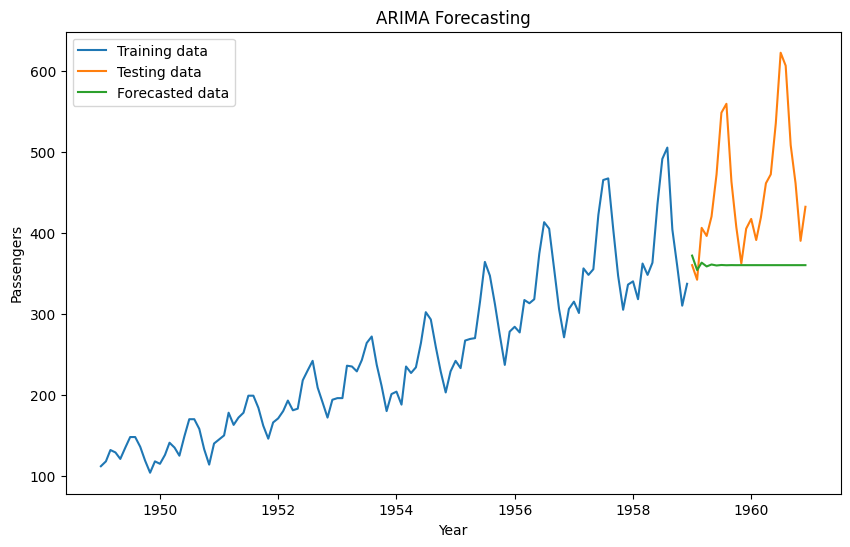

In [1484]:
plt.figure(figsize=(10,6))

#### perform the plotting of the training data
plt.plot(train.index, train['Passengers'], label = 'Training data')

#### perform the plotting of the testing data
plt.plot(test.index, test['Passengers'], label = 'Testing data')

#### perform the plotting of the forecasted data
plt.plot(test.index, future_values, label = 'Forecasted data')

#### give the title of the graph
plt.title("ARIMA Forecasting")

#### give the x axis of the graph
plt.xlabel("Year")

#### give the y axis of the graph
plt.ylabel("Passengers")

#### get the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the airline passengers per year ranging from 194 till 1960.

2.   Initially we saw that the trend was moving upwards . This is because:-----

        (a.)    With the increase in the number of years, number of airline passengers also increases.

3.  So we have applied the ARIMA forecasting on the above dataset.

4.  Here we have divided the dataset into training data ranging from 1949 till 1958 and the testing data ranging from 1959 till 1960.

5. Now ARIMA(1,1,1) is applied on the training data and the model is trained with it

    (a.)    ARIMA(1,1,1) represents

            (i.)    p = 1 ============>  Auto correlation. Here the current value depends upon the previous value.

            (ii.)   d = 1 ============>  First Order differencing. Here data is differenciated with the first order.

            (iii.)  q = 1 ============>  Moving Average = 1. Here the current value uses the previous error term to improve the future forecasted data.


6. So the ARIMA Model training is done on the past values ranging from 1949 till 1958.

7. The model forecasts the future values based on the past values of the training data adn the length of the forecasted value is equal to the length of the test data.

8. We can see from the graph that the forecasted data of the model is stable and the trend from it has completely been removed.

        (a.)    The mean, variance and the standard deviation of the forecasted values remains constant over a period of time.

9. So from this model, it is concluded that the non-stationary time series has been converted into stationary time series.

#### Step 12: Calculate the error between the actual and the predicted value

In [1485]:
from sklearn.metrics    import root_mean_squared_error

rmse = root_mean_squared_error(test,future_values)

print("Root Mean Squared error of the model is:", rmse)

Root Mean Squared error of the model is: 118.64452728647274


#### Step 13: Perform forecasting for the next 12 months

In [1486]:
#### get the forcasted values for the next 12 months

future_forecast = model_fit.forecast(steps=12)

print(future_forecast)

1959-01-01    371.774505
1959-02-01    353.970544
1959-03-01    363.085872
1959-04-01    358.418977
1959-05-01    360.808349
1959-06-01    359.585031
1959-07-01    360.211349
1959-08-01    359.890685
1959-09-01    360.054859
1959-10-01    359.970805
1959-11-01    360.013839
1959-12-01    359.991806
Freq: MS, Name: predicted_mean, dtype: float64


#### Step 14: Plot the future forecasted values

In [1487]:
test

,Passengers
date,
1959-01-01,360
1959-02-01,342
1959-03-01,406
1959-04-01,396
1959-05-01,420
1959-06-01,472
1959-07-01,548
1959-08-01,559
1959-09-01,463


In [1488]:
#### perform the forcasting of the test data

future_forecasting = model_fit.forecast(steps=len(test))

print(future_forecasting)

1959-01-01    371.774505
1959-02-01    353.970544
1959-03-01    363.085872
1959-04-01    358.418977
1959-05-01    360.808349
1959-06-01    359.585031
1959-07-01    360.211349
1959-08-01    359.890685
1959-09-01    360.054859
1959-10-01    359.970805
1959-11-01    360.013839
1959-12-01    359.991806
1960-01-01    360.003087
1960-02-01    359.997311
1960-03-01    360.000268
1960-04-01    359.998754
1960-05-01    359.999530
1960-06-01    359.999133
1960-07-01    359.999336
1960-08-01    359.999232
1960-09-01    359.999285
1960-10-01    359.999258
1960-11-01    359.999272
1960-12-01    359.999265
Freq: MS, Name: predicted_mean, dtype: float64


In [1489]:
#### Generate the future dates

future_dates = pd.date_range(
    start   =   df.index[-1]                    ,
    periods =   25                              ,
    freq    =   'MS'
)[1:]

In [1490]:
future_dates

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01',
               '1962-01-01', '1962-02-01', '1962-03-01', '1962-04-01',
               '1962-05-01', '1962-06-01', '1962-07-01', '1962-08-01',
               '1962-09-01', '1962-10-01', '1962-11-01', '1962-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [1491]:
#### Assign the future dates to the future forecasted values

future_forecasting.index = future_dates

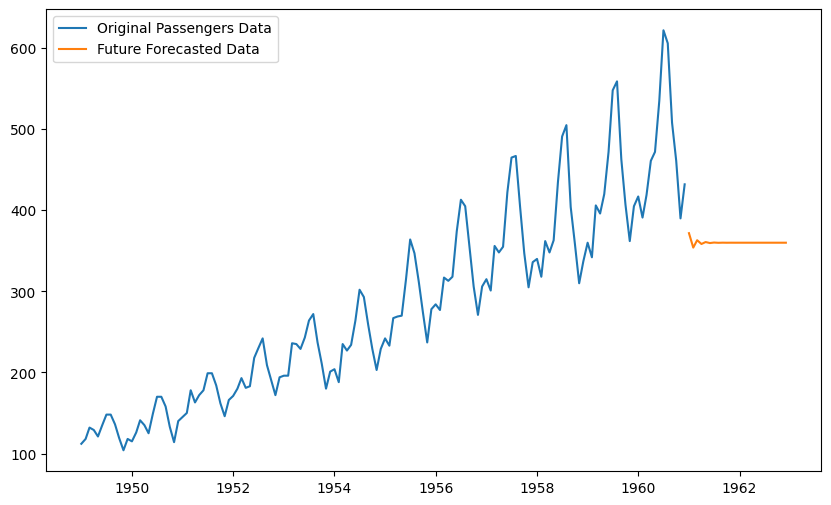

In [1492]:
#### perform the data visualization of the time series for the forecasted values

plt.figure(figsize=(10,6))

#### perform the plotting of the original time series
plt.plot(df.index, df['Passengers'], label = 'Original Passengers Data')

#### perform the plotting of the forecasted time series
plt.plot(future_forecasting.index, future_forecasting, label = 'Future Forecasted Data')

#### get the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts that the forecasted values for the next 12 months is stable and the trend has been removed from the dataset.

    (a.)    The mean, variance and the standard deviation of the forecasted values remains constant over a period of time.

2. So from this model, it is concluded that the non-stationary time series has been converted into stationary time series.